### Importing Dependencies:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Import dataset:

In [9]:
sna = pd.read_csv('This course DataSet/Social_Network_Ads.csv')
sna.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [10]:
# only work with numeric data
sna = sna.iloc[: , 2:]
sna.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [13]:
sna.shape

(400, 3)

In [12]:
# checking missing values becuase standardization is missing values sensitive 
sna.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

## Train Test spliting:

In [18]:
from sklearn.model_selection import train_test_split
x_train ,x_test, y_train, y_test = train_test_split(sna.drop('Purchased', axis = 1),
                                                     sna['Purchased'],
                                                     test_size = 0.3,
                                                     random_state = 42)
x_train.shape, x_test.shape

((280, 2), (120, 2))

## Standardization scalling:

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [22]:
# learn from only train data and transform it
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [24]:
x_train_scaled = pd.DataFrame(x_train_scaled, columns = x_train.columns)
x_test_scaled = pd.DataFrame (x_test_scaled , columns = x_test.columns)

In [28]:
# checking scaling actual vs scaled data
np.round(x_train.describe(), 2)

,Age,EstimatedSalary
count,280.00,280.00
mean,37.58,70589.29
std,10.20,33948.50
min,18.00,15000.00
25%,30.00,44000.00
50%,37.00,71000.00
75%,45.00,88000.00
max,60.00,150000.00


In [26]:
np.round(x_train_scaled.describe(), 2)

,Age,EstimatedSalary
count,280.00,280.00
mean,-0.00,0.00
std,1.00,1.00
min,-1.92,-1.64
25%,-0.74,-0.78
50%,-0.06,0.01
75%,0.73,0.51
max,2.20,2.34


In [30]:
# checking learned data mean from two col
scaler.mean_

array([3.75750000e+01, 7.05892857e+04])

In [32]:
# Actual data mean
sna.mean()

Age                   37.6550
EstimatedSalary    69742.5000
Purchased              0.3575
dtype: float64

## Effect of scaling:

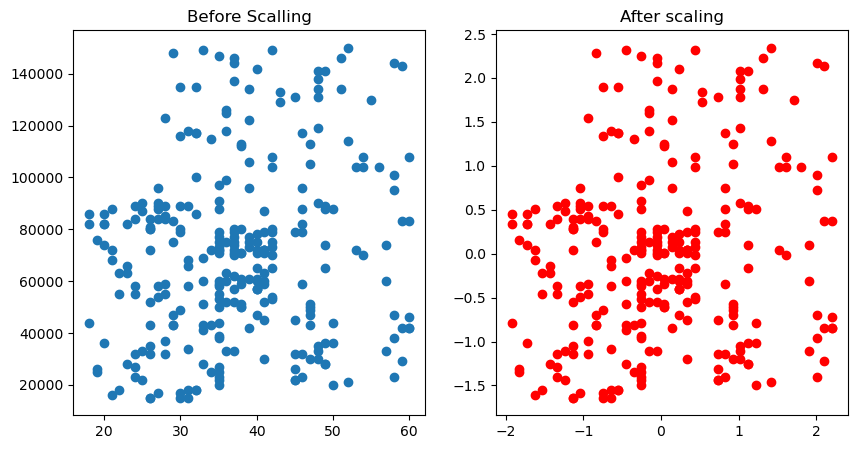

In [40]:
fig , (ax1, ax2) = plt.subplots(ncols = 2, figsize=(10,5))
ax1.scatter(x_train['Age'], x_train['EstimatedSalary'])
ax1.set_title('Before Scalling')

ax2.scatter(x_train_scaled['Age'], x_train_scaled['EstimatedSalary'], color = 'red')
ax2.set_title('After scaling')

plt.show()

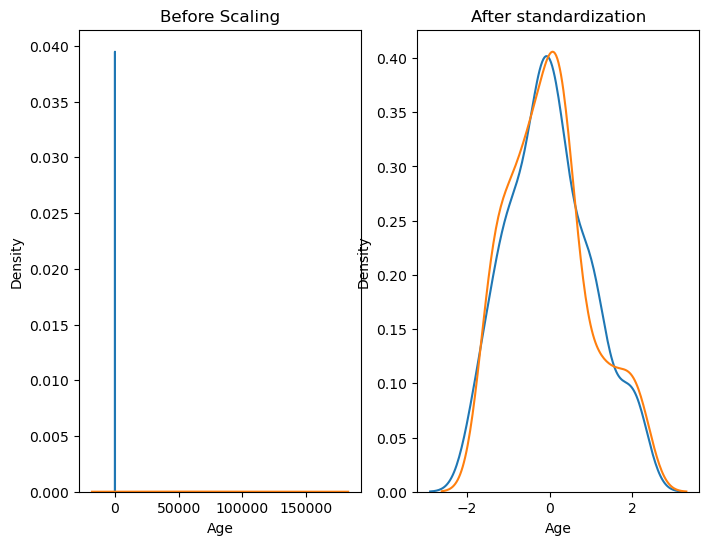

In [44]:
fig , (ax1, ax2) = plt.subplots(ncols = 2, figsize = (8, 6))
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax = ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax= ax1)

ax2.set_title('After standardization')
sns.kdeplot(x_train_scaled['Age'], ax = ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax = ax2)

plt.show()

## Why is scaling import 

In [56]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [57]:
# Creating instance of model
lr = LogisticRegression()
scaled_lr = LogisticRegression()


In [58]:
# Learning from training data 

lr.fit(x_train, y_train)
scaled_lr.fit(x_train_scaled, y_train)

LogisticRegression()

In [59]:
y_pred = lr.predict(x_test)
y_pred_scaled = scaled_lr.predict(x_test_scaled)

In [60]:
# checking accuracy of our prediction model
print(f'Actual: {accuracy_score(y_test,y_pred)}') 
print(f'Predicted: {accuracy_score(y_test, y_pred_scaled)}')

Actual: 0.85
Predicted: 0.85


## Loading New DataSet:

In [65]:
file_path = 'This course DataSet/Housing.csv'

In [64]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_regression
import warnings
file_path = 'This course DataSet/Housing.csv'
# Suppress warnings for clean output
warnings.filterwarnings('ignore')

class HousingDataPipeline:
    def __init__(self, file_path):
        """1. Loading Data"""
        self.df = pd.read_csv(file_path)
        print(f"Data Loaded Successfully. Shape: {self.df.shape}")

    def perform_eda(self):
        """2. Complete Exploratory Data Analysis (EDA)"""
        print("\n--- Starting EDA ---")
        
        # Plot 1: Target Variable (Price) Distribution
        plt.figure(figsize=(8, 5))
        sns.histplot(self.df['price'], kde=True, color='teal', bins=30)
        plt.title('Distribution of House Prices')
        plt.xlabel('Price')
        plt.ylabel('Frequency')
        plt.savefig('01_price_distribution.png')
        plt.close()
        
        # Plot 2: Correlation Heatmap
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        plt.figure(figsize=(10, 8))
        sns.heatmap(self.df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
        plt.title('Correlation Heatmap (Numerical Features)')
        plt.savefig('02_correlation_heatmap.png')
        plt.close()
        
        # Plot 3: Categorical vs Price
        plt.figure(figsize=(8, 5))
        sns.boxplot(x='airconditioning', y='price', data=self.df, palette='Set2')
        plt.title('Price vs Airconditioning')
        plt.savefig('03_price_vs_ac.png')
        plt.close()
        
        print("EDA completed. Plots saved as PNG files.")

    def data_cleaning_and_engineering(self):
        """1 & 3. Data Cleaning, Feature Engineering & Selection"""
        print("\n--- Starting Data Cleaning & Feature Engineering ---")
        
        # A. Mapping Binary Categorical to 1/0
        binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
        for col in binary_cols:
            self.df[col] = self.df[col].map({'yes': 1, 'no': 0})
            
        # B. One-Hot Encoding for multi-class categorical ('furnishingstatus')
        self.df = pd.get_dummies(self.df, columns=['furnishingstatus'], drop_first=True)
        # Ensure booleans are converted to integers (1/0)
        for col in self.df.columns:
            if self.df[col].dtype == 'bool':
                self.df[col] = self.df[col].astype(int)

        # C. Feature Engineering (Creating a meaningful new feature)
        # A logical feature 'total_rooms' combining main components
        self.df['total_rooms'] = self.df['bedrooms'] + self.df['bathrooms'] + self.df['guestroom']

        # D. Outlier Handling (Capping values using IQR)
        def cap_outliers(series):
            Q1 = series.quantile(0.25)
            Q3 = series.quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            return np.clip(series, lower_bound, upper_bound)

        self.df['area_capped'] = cap_outliers(self.df['area'])
        self.df['price'] = cap_outliers(self.df['price'])
        self.df.drop('area', axis=1, inplace=True) # Drop original uncapped area

        print("Data Cleaning and Feature Engineering completed.")
        return self.df

    def feature_selection(self):
        """3. Feature Selection using Mutual Information"""
        print("\n--- Feature Selection ---")
        X = self.df.drop('price', axis=1)
        y = self.df['price']

        # Measure dependency between features and target
        mi_scores = mutual_info_regression(X, y, random_state=42)
        mi_scores = pd.Series(mi_scores, name='MI_Scores', index=X.columns)
        mi_scores = mi_scores.sort_values(ascending=False)

        print("\nTop Features based on Mutual Information:")
        print(mi_scores.head(10)) # Top 10 important features
        
        # Save engineered dataset for Model Training
        self.df.to_csv('Housing_Engineered.csv', index=False)
        print("\nEngineered Dataset saved as 'Housing_Engineered.csv'")
        
        return mi_scores



In [1]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# --- 1. Dataset Banana ---
# Humare paas ek data hai jis mein Shehar (Nominal) aur Degree (Ordinal) hai
data = {
    'City': ['Lahore', 'Karachi', 'Islamabad', 'Lahore', 'Karachi'], 
    'Education': ['Matric', 'Bachelors', 'Masters', 'Matric', 'PhD'] 
}

df = pd.DataFrame(data)
print("--- Original Data ---")
print(df)


# --- 2. OrdinalEncoder (For Education) ---
# Yahan hum khud order define karte hain taake model ko rank samajh aaye
education_order = [['Matric', 'Bachelors', 'Masters', 'PhD']]

# Encoder initialize karna
ord_enc = OrdinalEncoder(categories=education_order)

# Fit aur Transform karna
df['Education_Encoded'] = ord_enc.fit_transform(df[['Education']])

print("\n--- After Ordinal Encoding (Education) ---")
print(df[['Education', 'Education_Encoded']])


# --- 3. OneHotEncoder (For City) ---
# sparse=False (ya sparse_output=False naye sklearn mein) is liye takay numpy array mile
# drop='first' is liye taake ek column kam ho jaye (Dummy variable trap se bachne ke liye)
ohe_enc = OneHotEncoder(sparse_output=False, drop='first')

# Fit aur Transform karna
city_encoded = ohe_enc.fit_transform(df[['City']])

# Naye columns ke naam nikalna (e.g., City_Karachi, City_Lahore)
city_columns = ohe_enc.get_feature_names_out(['City'])

# Encoded data ko DataFrame mein convert kar ke original data ke sath jodna
city_df = pd.DataFrame(city_encoded, columns=city_columns)
df_final = pd.concat([df, city_df], axis=1)

print("\n--- After OneHot Encoding (City) ---")

print("\n--- Final Machine Learning Ready Dataset ---")
# Original text columns drop kar dein kyunke model sirf numbers samajhta hai
df_ml_ready = df_final.drop(['City', 'Education'], axis=1)
print(df_ml_ready)

--- Original Data ---
        City  Education
0     Lahore     Matric
1    Karachi  Bachelors
2  Islamabad    Masters
3     Lahore     Matric
4    Karachi        PhD

--- After Ordinal Encoding (Education) ---
   Education  Education_Encoded
0     Matric                0.0
1  Bachelors                1.0
2    Masters                2.0
3     Matric                0.0
4        PhD                3.0

--- After OneHot Encoding (City) ---

--- Final Machine Learning Ready Dataset ---
   Education_Encoded  City_Karachi  City_Lahore
0                0.0           0.0          1.0
1                1.0           1.0          0.0
2                2.0           0.0          0.0
3                0.0           0.0          1.0
4                3.0           1.0          0.0


In [6]:
print(df_final[['City'] + list(city_columns)])

        City  City_Karachi  City_Lahore
0     Lahore           0.0          1.0
1    Karachi           1.0          0.0
2  Islamabad           0.0          0.0
3     Lahore           0.0          1.0
4    Karachi           1.0          0.0


In [4]:
print(city_columns)

['City_Karachi' 'City_Lahore']


In [2]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 1. Target labels (y) define karein (Indoor Object Detection classes)
y_targets = np.array(['Chair', 'Table', 'Bed', 'Chair', 'Table'])

# 2. LabelEncoder initialize karein
le = LabelEncoder()

# 3. fit_transform() lagayein (Yeh pattern seekhega aur numbers mein badal dega)
y_encoded = le.fit_transform(y_targets)

print("Original Labels:", y_targets)
print("Encoded Labels: ", y_encoded)
# Output: [1 2 0 1 2] 
# (Alphabetical sorting: Bed=0, Chair=1, Table=2)

# 4. Classes ka order check karna (Deployment mein zaroori hota hai)
print("Learned Classes:", le.classes_)

# 5. Inverse Transform (Jab model (0,1,2) predict kare, toh usay wapis text mein badalna)
model_predictions = np.array([0, 2, 1])
text_predictions = le.inverse_transform(model_predictions)

print("Numeric Predictions:", model_predictions)
print("Text Predictions:   ", text_predictions)
# Output: ['Bed', 'Table', 'Chair']



Original Labels: ['Chair' 'Table' 'Bed' 'Chair' 'Table']
Encoded Labels:  [1 2 0 1 2]
Learned Classes: ['Bed' 'Chair' 'Table']
Numeric Predictions: [0 2 1]
Text Predictions:    ['Bed' 'Table' 'Chair']


In [1]:
import datetime
today = datetime.date.today()
print("Today's date:", today)

Today's date: 2026-03-11
